# Notebook 03 — Model Training

**Project**: Diabetes Prediction  
**Goal**: Train and compare Logistic Regression, Random Forest, XGBoost, LightGBM, and Neural Network models.

Steps:
1. Imports and load processed data
2. Initialize ModelTrainer
3. Logistic Regression (baseline)
4. Random Forest with feature importance
5. XGBoost with hyperparameter tuning
6. LightGBM
7. Neural Network (optional)
8. Cross-validation for all models
9. Save all models
10. Comparison table

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import (
    FEATURE_COLUMNS, TARGET_COLUMN, RANDOM_STATE, MODELS_DIR,
    PROCESSED_DATA_DIR, MODEL_PARAMS, CV_FOLDS, PLOTS_DIR
)
from src.models import (
    ModelTrainer, get_logistic_regression, get_random_forest,
    get_xgboost, get_lightgbm, get_neural_network,
    train_model, cross_validate_model, hyperparameter_tuning, save_model
)
from src.evaluation import calculate_metrics
from src.visualization import plot_feature_importance

print('Imports successful.')

Imports successful.


## 1. Load Processed Data

In [2]:
def load_processed_data():
    """Load saved processed splits, or create synthetic data if not available."""
    x_train_scaled_path = PROCESSED_DATA_DIR / 'X_train_scaled.npy'
    x_test_scaled_path  = PROCESSED_DATA_DIR / 'X_test_scaled.npy'
    y_train_path        = PROCESSED_DATA_DIR / 'y_train_resampled.csv'
    y_test_path         = PROCESSED_DATA_DIR / 'y_test.csv'
    x_train_path        = PROCESSED_DATA_DIR / 'X_train.csv'
    x_test_path         = PROCESSED_DATA_DIR / 'X_test.csv'

    if x_train_scaled_path.exists() and y_train_path.exists():
        X_train_scaled = np.load(str(x_train_scaled_path))
        X_test_scaled  = np.load(str(x_test_scaled_path))
        y_train = pd.read_csv(y_train_path).squeeze()
        y_test  = pd.read_csv(y_test_path).squeeze()
        X_train_raw = pd.read_csv(x_train_path) if x_train_path.exists() else None
        X_test_raw  = pd.read_csv(x_test_path)  if x_test_path.exists()  else None
        print('Loaded from processed files.')
    else:
        print('Processed files not found. Generating synthetic data...')
        from sklearn.datasets import make_classification
        X, y = make_classification(
            n_samples=3000, n_features=21, n_informative=15,
            n_classes=2, n_clusters_per_class=1, random_state=RANDOM_STATE
        )
        from sklearn.model_selection import train_test_split
        X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
        )
        y_train = pd.Series(y_train, name=TARGET_COLUMN)
        y_test  = pd.Series(y_test,  name=TARGET_COLUMN)
        X_train_raw = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
        X_test_raw  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLUMNS)

    return X_train_scaled, X_test_scaled, y_train, y_test, X_train_raw, X_test_raw


X_train, X_test, y_train, y_test, X_train_raw, X_test_raw = load_processed_data()

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train dist  : {dict(pd.Series(y_train).value_counts().sort_index())}')
print(f'y_test  dist  : {dict(pd.Series(y_test).value_counts().sort_index())}')

Loaded from processed files.
X_train shape : (349334, 21)
X_test  shape : (50736, 21)
y_train dist  : {0.0: np.int64(174667), 1.0: np.int64(174667)}
y_test  dist  : {0.0: np.int64(43667), 1.0: np.int64(7069)}


## 2. Initialize ModelTrainer

In [3]:
trainer = ModelTrainer()
print('ModelTrainer initialised.')

ModelTrainer initialised.


## 3. Logistic Regression (Baseline)

In [4]:
lr = get_logistic_regression({'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs'})
trainer.add_model('LogisticRegression', lr)
trainer.train('LogisticRegression', X_train, y_train)

lr_model = trainer.get_model('LogisticRegression')
lr_pred  = lr_model.predict(X_test)
lr_prob  = lr_model.predict_proba(X_test)

lr_metrics = calculate_metrics(y_test, lr_pred, lr_prob)
trainer.record_result('LogisticRegression', lr_metrics)
print('Logistic Regression metrics:')
for k, v in lr_metrics.items():
    print(f'  {k:<25}: {v:.4f}')

Logistic Regression metrics:
  accuracy                 : 0.7351
  precision_macro          : 0.6318
  precision_weighted       : 0.8611
  recall_macro             : 0.7458
  recall_weighted          : 0.7351
  f1_macro                 : 0.6353
  f1_weighted              : 0.7729
  roc_auc                  : 0.8208
  specificity              : 0.7458


## 4. Random Forest with Feature Importance

In [5]:
rf = get_random_forest({'n_estimators': 100, 'max_depth': 10, 'n_jobs': -1})
trainer.add_model('RandomForest', rf)
trainer.train('RandomForest', X_train, y_train)

rf_model = trainer.get_model('RandomForest')
rf_pred  = rf_model.predict(X_test)
rf_prob  = rf_model.predict_proba(X_test)

rf_metrics = calculate_metrics(y_test, rf_pred, rf_prob)
trainer.record_result('RandomForest', rf_metrics)
print('Random Forest metrics:')
for k, v in rf_metrics.items():
    print(f'  {k:<25}: {v:.4f}')

Random Forest metrics:
  accuracy                 : 0.7864
  precision_macro          : 0.6427
  precision_weighted       : 0.8519
  recall_macro             : 0.7244
  recall_weighted          : 0.7864
  f1_macro                 : 0.6608
  f1_weighted              : 0.8097
  roc_auc                  : 0.8175
  specificity              : 0.7244


In [6]:
# Feature importance
feature_names = FEATURE_COLUMNS if X_train_raw is not None else [f'f{i}' for i in range(X_train.shape[1])]
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 10 features by Random Forest importance:')
print(importance_df.head(10).to_string(index=False))

plot_feature_importance(
    importance_df, top_n=15,
    save_path=str(PLOTS_DIR / 'rf_feature_importance.png')
)

Top 10 features by Random Forest importance:
             feature  importance
             GenHlth    0.289055
              HighBP    0.163226
                 BMI    0.150110
                 Age    0.133797
              Income    0.072962
            HighChol    0.067803
            PhysHlth    0.032132
           Education    0.028245
            DiffWalk    0.024735
HeartDiseaseorAttack    0.008086


## 5. XGBoost with Hyperparameter Tuning

In [7]:
# Quick tuning with a small grid (use larger grid in production)
xgb_base = get_xgboost()
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
}

print('Running XGBoost RandomizedSearchCV (this may take a few minutes)...')
xgb_best, xgb_best_params = hyperparameter_tuning(
    xgb_base, xgb_param_grid,
    X_train, y_train,
    cv=3, method='random', n_iter=8,
    scoring='accuracy'
)
print(f'Best XGBoost params: {xgb_best_params}')

trainer.add_model('XGBoost', xgb_best)
trainer._trained['XGBoost'] = True  # already fitted by search

xgb_pred = xgb_best.predict(X_test)
xgb_prob = xgb_best.predict_proba(X_test)

xgb_metrics = calculate_metrics(y_test, xgb_pred, xgb_prob)
trainer.record_result('XGBoost', xgb_metrics)
print('XGBoost metrics:')
for k, v in xgb_metrics.items():
    print(f'  {k:<25}: {v:.4f}')

Running XGBoost RandomizedSearchCV (this may take a few minutes)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best XGBoost params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
XGBoost metrics:
  accuracy                 : 0.8632
  precision_macro          : 0.7030
  precision_weighted       : 0.8347
  recall_macro             : 0.5974
  recall_weighted          : 0.8632
  f1_macro                 : 0.6210
  f1_weighted              : 0.8395
  roc_auc                  : 0.8239
  specificity              : 0.5974


## 6. LightGBM

In [8]:
lgbm = get_lightgbm({'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 63})
trainer.add_model('LightGBM', lgbm)
trainer.train('LightGBM', X_train, y_train)

lgbm_model = trainer.get_model('LightGBM')
lgbm_pred  = lgbm_model.predict(X_test)
lgbm_prob  = lgbm_model.predict_proba(X_test)

lgbm_metrics = calculate_metrics(y_test, lgbm_pred, lgbm_prob)
trainer.record_result('LightGBM', lgbm_metrics)
print('LightGBM metrics:')
for k, v in lgbm_metrics.items():
    print(f'  {k:<25}: {v:.4f}')

LightGBM metrics:
  accuracy                 : 0.8636
  precision_macro          : 0.7053
  precision_weighted       : 0.8331
  recall_macro             : 0.5860
  recall_weighted          : 0.8636
  f1_macro                 : 0.6079
  f1_weighted              : 0.8363
  roc_auc                  : 0.8261
  specificity              : 0.5860


## 7. Neural Network (Optional — requires TensorFlow)

In [9]:
try:
    import tensorflow as tf
    from tensorflow import keras
    print(f'TensorFlow version: {tf.__version__}')

    input_dim = X_train.shape[1]
    nn_model = get_neural_network(input_dim=input_dim, num_classes=2)
    nn_model.summary()

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1
    )

    history = nn_model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=30,
        batch_size=256,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[1].plot(history.history['accuracy'], label='Train')
    axes[1].plot(history.history['val_accuracy'], label='Val')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(str(PLOTS_DIR / 'nn_training_history.png'), bbox_inches='tight')
    plt.show()

    # Sigmoid output — shape (n, 1); squeeze to 1D probability of class 1
    nn_prob_raw = nn_model.predict(X_test).flatten()
    nn_pred = (nn_prob_raw > 0.5).astype(int)
    nn_metrics = calculate_metrics(y_test, nn_pred, nn_prob_raw)
    print('Neural Network metrics:')
    for k, v in nn_metrics.items():
        print(f'  {k:<25}: {v:.4f}')

    nn_model.save(str(MODELS_DIR / 'neural_network.h5'))
    print('Neural network saved.')

    # Add to trainer manually
    trainer.record_result('NeuralNetwork', nn_metrics)

except ImportError:
    print('TensorFlow not installed — skipping neural network training.')
    print('Install with: pip install tensorflow')

TensorFlow not installed — skipping neural network training.
Install with: pip install tensorflow


## 8. Cross-Validation for All Models

In [10]:
print('Running cross-validation (3 folds for speed)...')
cv_results = {}

for name in ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM']:
    model = trainer.get_model(name)
    cv_res = cross_validate_model(model, X_train, y_train, cv=3, scoring='accuracy')
    cv_results[name] = cv_res
    print(f'{name:<22} CV Accuracy: {cv_res["mean_score"]:.4f} ± {cv_res["std_score"]:.4f}')

Running cross-validation (3 folds for speed)...


LogisticRegression     CV Accuracy: 0.7550 ± 0.0006


RandomForest           CV Accuracy: 0.8387 ± 0.0010


XGBoost                CV Accuracy: 0.9157 ± 0.0005


LightGBM               CV Accuracy: 0.9199 ± 0.0003


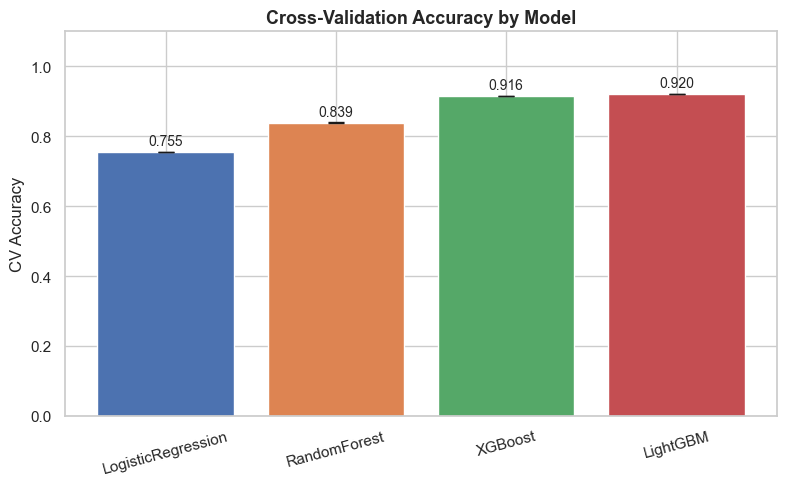

In [11]:
# Visualise CV scores
names = list(cv_results.keys())
means = [cv_results[n]['mean_score'] for n in names]
stds  = [cv_results[n]['std_score']  for n in names]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, means, yerr=stds, capsize=6, color=['#4c72b0','#dd8452','#55a868','#c44e52'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('CV Accuracy')
ax.set_title('Cross-Validation Accuracy by Model', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{mean:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'cv_comparison.png'), bbox_inches='tight')
plt.show()

## 9. Save All Trained Models

In [12]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
trainer.save_all(str(MODELS_DIR))
print('\nSaved models:')
for p in sorted(MODELS_DIR.iterdir()):
    print(f'  {p.name}')


Saved models:
  .gitkeep
  LightGBM.pkl
  LogisticRegression.pkl
  RandomForest.pkl
  XGBoost.pkl
  scaler.pkl


## 10. Model Comparison Table

In [13]:
comparison = trainer.get_comparison()
print('Model comparison (sorted by ROC-AUC):')
comparison

Model comparison (sorted by ROC-AUC):


,accuracy,precision_macro,precision_weighted,recall_macro,recall_weighted,f1_macro,f1_weighted,roc_auc,specificity
LightGBM,0.863647,0.705250,0.833067,0.585967,0.863647,0.607878,0.836320,0.826068,0.585967
XGBoost,0.863174,0.702986,0.834676,0.597371,0.863174,0.620950,0.839524,0.823899,0.597371
LogisticRegression,0.735139,0.631818,0.861073,0.745768,0.735139,0.635299,0.772944,0.820792,0.745768
RandomForest,0.786365,0.642682,0.851851,0.724427,0.786365,0.660800,0.809668,0.817490,0.724427


In [14]:
# Highlight best model per metric
key_metrics = ['accuracy', 'roc_auc', 'f1_weighted', 'f1_macro']
for metric in key_metrics:
    if metric in comparison.columns:
        best = comparison[metric].idxmax()
        best_val = comparison.loc[best, metric]
        print(f'Best {metric:<22}: {best} ({best_val:.4f})')

Best accuracy              : LightGBM (0.8636)
Best roc_auc               : LightGBM (0.8261)
Best f1_weighted           : XGBoost (0.8395)
Best f1_macro              : RandomForest (0.6608)


In [15]:
# Save comparison to CSV
from src.config import REPORTS_DIR
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
comparison.to_csv(str(REPORTS_DIR / 'model_comparison.csv'))
print(f'Comparison saved to {REPORTS_DIR / "model_comparison.csv"}')

print('\nNext step: 04_evaluation.ipynb')

Comparison saved to /Users/tathagatadebnath/Downloads/federated_ML/v1-basic-ml/results/reports/model_comparison.csv

Next step: 04_evaluation.ipynb
